In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-06-10 20:03:44.411461: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-10 20:03:45.873330: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-10 20:03:48.762133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-10 20:03:53.704824: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [4]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [5]:



data = awgn(data, snr_range)

In [ ]:
print(data)

In [6]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)



In [10]:
data=augmented_sample

In [19]:
data.shape

(5000, 8192)

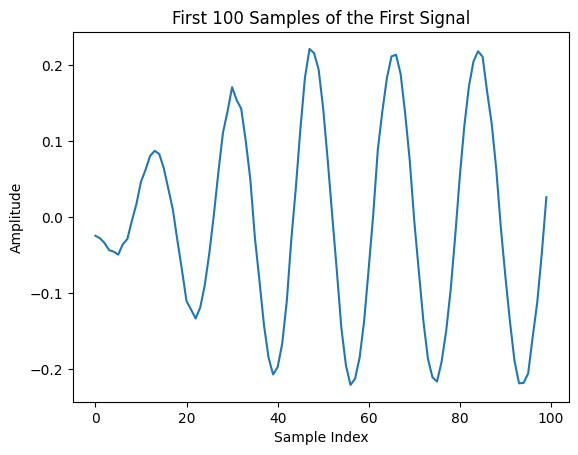

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

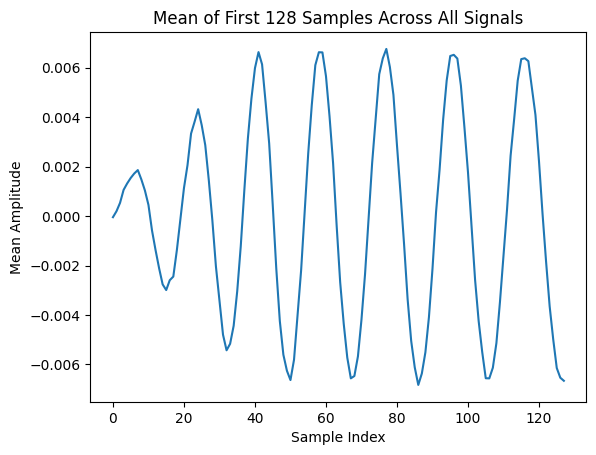

Suspected Preamble: [-4.31721960e-05+1.08153740e-03j  1.98935606e-04+1.29878295e-03j
  5.37109481e-04+1.21079759e-03j  1.06153096e-03+1.30421717e-03j
  1.32130560e-03+7.75297319e-04j  1.54278542e-03+2.68955231e-04j
  1.72398049e-03-5.34600403e-05j  1.86230133e-03-5.47024495e-04j
  1.48412281e-03-1.24223178e-03j  1.03911426e-03-1.87750180e-03j
  4.53770396e-04-2.16666495e-03j -5.78210005e-04-2.12083415e-03j
 -1.37281918e-03-2.06817817e-03j -2.10750048e-03-1.71597813e-03j
 -2.76090935e-03-8.33074440e-04j -2.98988244e-03+2.38341025e-04j
 -2.59149037e-03+1.32060779e-03j -2.44478714e-03+2.18617002e-03j
 -1.37680022e-03+2.85034725e-03j -1.11794671e-04+3.33128774e-03j
  1.13333634e-03+3.37771009e-03j  2.06217978e-03+3.01744195e-03j
  3.33879122e-03+2.18871057e-03j  3.82021863e-03+8.03024817e-04j
  4.32458824e-03-7.35058643e-04j  3.68019767e-03-2.07926598e-03j
  2.87147916e-03-3.66661338e-03j  1.45077620e-03-4.32388495e-03j
 -1.71786033e-04-5.03714672e-03j -2.03055225e-03-4.67537701e-03j
 -3.4

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


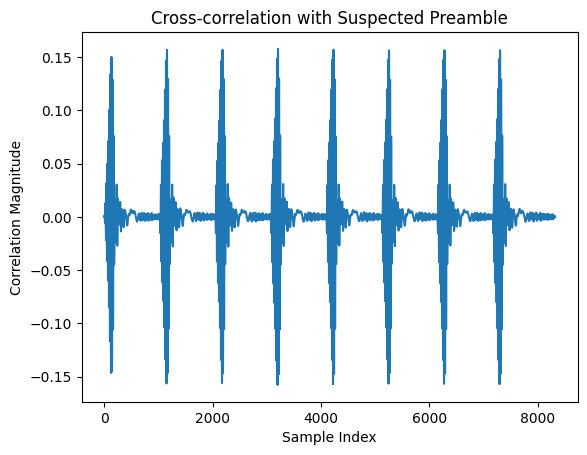

Peak correlation index: 3201
Peak correlation value: (-0.028290017762267403+0.15720579472713542j)
Synchronized signal start index: 3074


In [13]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [14]:
import numpy as np

# Given values
peak_index =3201
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.1738645 +0.12343196j -0.15456394+0.14728654j -0.13975462+0.17322973j
 -0.10389954+0.19477159j -0.06662217+0.21730117j -0.00842774+0.21509767j
  0.04505132+0.21533708j  0.10538329+0.19511633j  0.16512365+0.15668163j
  0.19263222+0.10108768j  0.21029919+0.04711404j  0.21252576-0.03905659j
  0.19387032-0.10643063j  0.13907174-0.16900264j  0.0905853 -0.19851932j
  0.01647339-0.21903121j -0.06188906-0.21555233j -0.13007007-0.17316729j
 -0.18516012-0.12306508j -0.2118566 -0.03922786j -0.21990848+0.03518728j
 -0.19222167+0.11315568j -0.13392337+0.17664963j -0.07260748+0.21000652j
  0.00298978+0.21242187j  0.0907276 +0.21225403j  0.1499353 +0.15796304j
  0.19671441+0.09966162j  0.22735574+0.01149507j  0.21170556-0.06201098j
  0.17710361-0.13823549j  0.1222918 -0.1804519j   0.03534516-0.21121429j
 -0.03893584-0.21763289j -0.11460879-0.18743626j -0.17878744-0.13817896j
 -0.21276613-0.05461936j -0.22330811+0.01787109j -0.20197319+0.08719908j
 -0.14808942+0.16092361j -0.083

In [15]:
preamble=suspected_preamble
data_input=data

In [16]:
preamble

array([-0.1738645 +0.12343196j, -0.15456394+0.14728654j,
       -0.13975462+0.17322973j, -0.10389954+0.19477159j,
       -0.06662217+0.21730117j, -0.00842774+0.21509767j,
        0.04505132+0.21533708j,  0.10538329+0.19511633j,
        0.16512365+0.15668163j,  0.19263222+0.10108768j,
        0.21029919+0.04711404j,  0.21252576-0.03905659j,
        0.19387032-0.10643063j,  0.13907174-0.16900264j,
        0.0905853 -0.19851932j,  0.01647339-0.21903121j,
       -0.06188906-0.21555233j, -0.13007007-0.17316729j,
       -0.18516012-0.12306508j, -0.2118566 -0.03922786j,
       -0.21990848+0.03518728j, -0.19222167+0.11315568j,
       -0.13392337+0.17664963j, -0.07260748+0.21000652j,
        0.00298978+0.21242187j,  0.0907276 +0.21225403j,
        0.1499353 +0.15796304j,  0.19671441+0.09966162j,
        0.22735574+0.01149507j,  0.21170556-0.06201098j,
        0.17710361-0.13823549j,  0.1222918 -0.1804519j ,
        0.03534516-0.21121429j, -0.03893584-0.21763289j,
       -0.11460879-0.18743626j,

In [17]:
import numpy as np




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 7180


/tmp/ipykernel_3467/4082080103.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]


In [18]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([-0.1738645 +0.12343196j, -0.15456394+0.14728654j,
       -0.13975462+0.17322973j, -0.10389954+0.19477159j,
       -0.06662217+0.21730117j, -0.00842774+0.21509767j,
        0.04505132+0.21533708j,  0.10538329+0.19511633j,
        0.16512365+0.15668163j,  0.19263222+0.10108768j,
        0.21029919+0.04711404j,  0.21252576-0.03905659j,
        0.19387032-0.10643063j,  0.13907174-0.16900264j,
        0.0905853 -0.19851932j,  0.01647339-0.21903121j,
       -0.06188906-0.21555233j, -0.13007007-0.17316729j,
       -0.18516012-0.12306508j, -0.2118566 -0.03922786j,
       -0.21990848+0.03518728j, -0.19222167+0.11315568j,
       -0.13392337+0.17664963j, -0.07260748+0.21000652j,
        0.00298978+0.21242187j,  0.0907276 +0.21225403j,
        0.1499353 +0.15796304j,  0.19671441+0.09966162j,
        0.22735574+0.01149507j,  0.21170556-0.06201098j,
        0.17710361-0.13823549j,  0.1222918 -0.1804519j ,
        0.03534516-0.21121429j, -0.03893584-0.21763289j,
       -0.11460879-0.18743626j, -0.17878744-0.13817896j,
       -0.21276613-0.05461936j, -0.22330811+0.01787109j,
       -0.20197319+0.08719908j, -0.14808942+0.16092361j,
       -0.08378071+0.20274028j, -0.01093119+0.22040712j,
        0.06040256+0.20132441j,  0.13644552+0.16958654j,
        0.18507047+0.11326862j,  0.21610883+0.04163197j,
        0.2257345 -0.04161979j,  0.19587317-0.11307826j,
        0.144277  -0.17565659j,  0.06835024-0.21245512j,
       -0.00641604-0.21977185j, -0.07986973-0.19723653j,
       -0.14211072-0.16206443j, -0.18994349-0.10108775j,
       -0.21664077-0.03664236j, -0.20603713+0.04732837j,
       -0.18649252+0.11815878j, -0.14219941+0.17739611j,
       -0.07102945+0.2080584j , -0.00416943+0.21934778j,
        0.07685421+0.20434846j,  0.1439486 +0.16650646j,
        0.18676354+0.09974641j,  0.21669744+0.02741229j,
        0.2192548 -0.04169342j,  0.19415848-0.10387666j,
        0.14445195-0.16393184j,  0.07735967-0.20209343j,
        0.00995574-0.21766088j, -0.0689355 -0.20811489j,
       -0.13862241-0.16935124j, -0.19036202-0.1181923j ,
       -0.20986651-0.05353925j, -0.22284465+0.02537412j,
       -0.19213941+0.09041645j, -0.1540487 +0.15599389j,
       -0.10084072+0.19504232j, -0.02067569+0.21706162j,
        0.04872991+0.21225304j,  0.11604885+0.18182357j,
        0.17565222+0.13595607j,  0.21132713+0.07414597j,
        0.22269903+0.00042232j,  0.20533204-0.07235312j,
        0.17490217-0.13147084j,  0.12342878-0.18237384j,
        0.05194498-0.2122228j , -0.01589975-0.22536276j,
       -0.07844987-0.20781868j, -0.13934413-0.16903925j,
       -0.19491045-0.12457592j, -0.21182873-0.04828196j,
       -0.21259922+0.02367411j, -0.20226516+0.08954343j,
       -0.15782293+0.14594593j, -0.11239957+0.19419009j,
       -0.03499455+0.22473291j,  0.02755328+0.21544528j,
        0.0942449 +0.18970639j,  0.15898974+0.15817312j,
        0.185723  +0.10059765j,  0.21121086+0.03763225j,
        0.21022291-0.03028766j,  0.20139996-0.10702455j,
        0.15838792-0.15880519j,  0.10442206-0.19605667j,
        0.04441855-0.21090653j, -0.02776534-0.22422081j,
       -0.09645227-0.19589662j, -0.15397185-0.15799057j,
       -0.19503861-0.10473173j, -0.22016981-0.0372823j ,
       -0.22171627+0.02846856j, -0.19862869+0.08929692j,
       -0.16808939+0.14935635j, -0.11285707+0.18841087j,
       -0.05101419+0.20930481j,  0.01928495+0.21967561j,
        0.08673772+0.20234295j,  0.13321056+0.17384761j,
        0.1850388 +0.12141276j,  0.20970352+0.05822277j,
        0.21905053-0.00529018j,  0.21220995-0.06439165j,
        0.18196311-0.12957512j,  0.1320784 -0.17929444j,
        0.08068164-0.20579823j,  0.02153133-0.218212j  ])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[-0.1738645   0.12343196 -0.15456394  0.14728654 -0.13975462  0.17322973
 -0.10389954  0.19477159 -0.06662217  0.21730117 -0.00842774  0.21509767
  0.04505132  0.21533708  0.10538329  0.19511633  0.16512365  0.15668163
  0.19263222  0.10108768  0.21029919  0.04711404  0.21252576 -0.03905659
  0.19387032 -0.10643063  0.13907174 -0.16900264  0.0905853  -0.19851932
  0.01647339 -0.21903121 -0.06188906 -0.21555233 -0.13007007 -0.17316729
 -0.18516012 -0.12306508 -0.2118566  -0.03922786 -0.21990848  0.03518728
 -0.19222167  0.11315568 -0.13392337  0.17664963 -0.07260748  0.21000652
  0.00298978  0.21242187  0.0907276   0.21225403  0.1499353   0.15796304
  0.19671441  0.09966162  0.22735574  0.01149507  0.21170556 -0.06201098
  0.17710361 -0.13823549  0.1222918  -0.1804519   0.03534516 -0.21121429
 -0.03893584 -0.21763289 -0.11460879 -0.18743626 -0.17878744 -0.13817896
 -0.21276613 -0.05461936 -0.22330811  0.01787109 -0.20197319  0.08719908
 -0.14808942  0.16092361 -0.08378071  0.20274028 -0

In [19]:
pilot_sequence

array([-0.1738645 ,  0.12343196, -0.15456394,  0.14728654, -0.13975462,
        0.17322973, -0.10389954,  0.19477159, -0.06662217,  0.21730117,
       -0.00842774,  0.21509767,  0.04505132,  0.21533708,  0.10538329,
        0.19511633,  0.16512365,  0.15668163,  0.19263222,  0.10108768,
        0.21029919,  0.04711404,  0.21252576, -0.03905659,  0.19387032,
       -0.10643063,  0.13907174, -0.16900264,  0.0905853 , -0.19851932,
        0.01647339, -0.21903121, -0.06188906, -0.21555233, -0.13007007,
       -0.17316729, -0.18516012, -0.12306508, -0.2118566 , -0.03922786,
       -0.21990848,  0.03518728, -0.19222167,  0.11315568, -0.13392337,
        0.17664963, -0.07260748,  0.21000652,  0.00298978,  0.21242187,
        0.0907276 ,  0.21225403,  0.1499353 ,  0.15796304,  0.19671441,
        0.09966162,  0.22735574,  0.01149507,  0.21170556, -0.06201098,
        0.17710361, -0.13823549,  0.1222918 , -0.1804519 ,  0.03534516,
       -0.21121429, -0.03893584, -0.21763289, -0.11460879, -0.18

In [21]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
pilot=np.array([-0.1738645 ,  0.12343196, -0.15456394,  0.14728654, -0.13975462,
        0.17322973, -0.10389954,  0.19477159, -0.06662217,  0.21730117,
       -0.00842774,  0.21509767,  0.04505132,  0.21533708,  0.10538329,
        0.19511633,  0.16512365,  0.15668163,  0.19263222,  0.10108768,
        0.21029919,  0.04711404,  0.21252576, -0.03905659,  0.19387032,
       -0.10643063,  0.13907174, -0.16900264,  0.0905853 , -0.19851932,
        0.01647339, -0.21903121, -0.06188906, -0.21555233, -0.13007007,
       -0.17316729, -0.18516012, -0.12306508, -0.2118566 , -0.03922786,
       -0.21990848,  0.03518728, -0.19222167,  0.11315568, -0.13392337,
        0.17664963, -0.07260748,  0.21000652,  0.00298978,  0.21242187,
        0.0907276 ,  0.21225403,  0.1499353 ,  0.15796304,  0.19671441,
        0.09966162,  0.22735574,  0.01149507,  0.21170556, -0.06201098,
        0.17710361, -0.13823549,  0.1222918 , -0.1804519 ,  0.03534516,
       -0.21121429, -0.03893584, -0.21763289, -0.11460879, -0.18743626,
       -0.17878744, -0.13817896, -0.21276613, -0.05461936, -0.22330811,
        0.01787109, -0.20197319,  0.08719908, -0.14808942,  0.16092361,
       -0.08378071,  0.20274028, -0.01093119,  0.22040712,  0.06040256,
        0.20132441,  0.13644552,  0.16958654,  0.18507047,  0.11326862,
        0.21610883,  0.04163197,  0.2257345 , -0.04161979,  0.19587317,
       -0.11307826,  0.144277  , -0.17565659,  0.06835024, -0.21245512,
       -0.00641604, -0.21977185, -0.07986973, -0.19723653, -0.14211072,
       -0.16206443, -0.18994349, -0.10108775, -0.21664077, -0.03664236,
       -0.20603713,  0.04732837, -0.18649252,  0.11815878, -0.14219941,
        0.17739611, -0.07102945,  0.2080584 , -0.00416943,  0.21934778,
        0.07685421,  0.20434846,  0.1439486 ,  0.16650646,  0.18676354,
        0.09974641,  0.21669744,  0.02741229,  0.2192548 , -0.04169342,
        0.19415848, -0.10387666,  0.14445195, -0.16393184,  0.07735967,
       -0.20209343,  0.00995574, -0.21766088, -0.0689355 , -0.20811489,
       -0.13862241, -0.16935124, -0.19036202, -0.1181923 , -0.20986651,
       -0.05353925, -0.22284465,  0.02537412, -0.19213941,  0.09041645,
       -0.1540487 ,  0.15599389, -0.10084072,  0.19504232, -0.02067569,
        0.21706162,  0.04872991,  0.21225304,  0.11604885,  0.18182357,
        0.17565222,  0.13595607,  0.21132713,  0.07414597,  0.22269903,
        0.00042232,  0.20533204, -0.07235312,  0.17490217, -0.13147084,
        0.12342878, -0.18237384,  0.05194498, -0.2122228 , -0.01589975,
       -0.22536276, -0.07844987, -0.20781868, -0.13934413, -0.16903925,
       -0.19491045, -0.12457592, -0.21182873, -0.04828196, -0.21259922,
        0.02367411, -0.20226516,  0.08954343, -0.15782293,  0.14594593,
       -0.11239957,  0.19419009, -0.03499455,  0.22473291,  0.02755328,
        0.21544528,  0.0942449 ,  0.18970639,  0.15898974,  0.15817312,
        0.185723  ,  0.10059765,  0.21121086,  0.03763225,  0.21022291,
       -0.03028766,  0.20139996, -0.10702455,  0.15838792, -0.15880519,
        0.10442206, -0.19605667,  0.04441855, -0.21090653, -0.02776534,
       -0.22422081, -0.09645227, -0.19589662, -0.15397185, -0.15799057,
       -0.19503861, -0.10473173, -0.22016981, -0.0372823 , -0.22171627,
        0.02846856, -0.19862869,  0.08929692, -0.16808939,  0.14935635,
       -0.11285707,  0.18841087, -0.05101419,  0.20930481,  0.01928495,
        0.21967561,  0.08673772,  0.20234295,  0.13321056,  0.17384761,
        0.1850388 ,  0.12141276,  0.20970352,  0.05822277,  0.21905053,
       -0.00529018,  0.21220995, -0.06439165,  0.18196311, -0.12957512,
        0.1320784 , -0.17929444,  0.08068164, -0.20579823,  0.02153133,
       -0.218212  ])




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/tmp/ipykernel_3467/1610598915.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]


Most Common Synchronization Offset: 7180


In [24]:
data=compensated_data

In [27]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalized_data = normalize_data(data)

In [28]:
data=normalized_data

In [51]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [37]:
data_real_values.shape
data_real_values.shape[1]

1017

In [28]:
data_real_values.shape[1]

7170

In [38]:
data_real_values.shape

(5000, 1017, 2)

In [40]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [41]:
input_data=data_real_values

In [43]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [44]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1],2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-06-05 20:49:25.654457: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.
2024-06-05 20:49:25.695710: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.
2024-06-05 20:49:25.710057: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.


In [57]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(512, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=60, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/60


125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.1509 - loss: 2.1333 - val_accuracy: 0.4990 - val_loss: 1.1496 - learning_rate: 0.0010
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4632 - loss: 1.1546 - val_accuracy: 0.7140 - val_loss: 0.6663 - learning_rate: 0.0010
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5952 - loss: 0.8374 - val_accuracy: 0.6870 - val_loss: 0.6148 - learning_rate: 0.0010
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6501 - loss: 0.7509 - val_accuracy: 0.6670 - val_loss: 0.6211 - learning_rate: 0.0010
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6538 - loss: 0.6970 - val_accuracy: 0.6530 - val_loss: 0.5668 - learning_rate: 0.0010
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6616 - loss: 0.6630 - val_accuracy: 0.8360 - val_loss: 0.4375 - learning_rate: 0.0010
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6978 - loss: 0.5955 - val_

In [58]:
model_to_train.save('CNN_A_model.h5')

In [59]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('CNN_A_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 95.00%


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


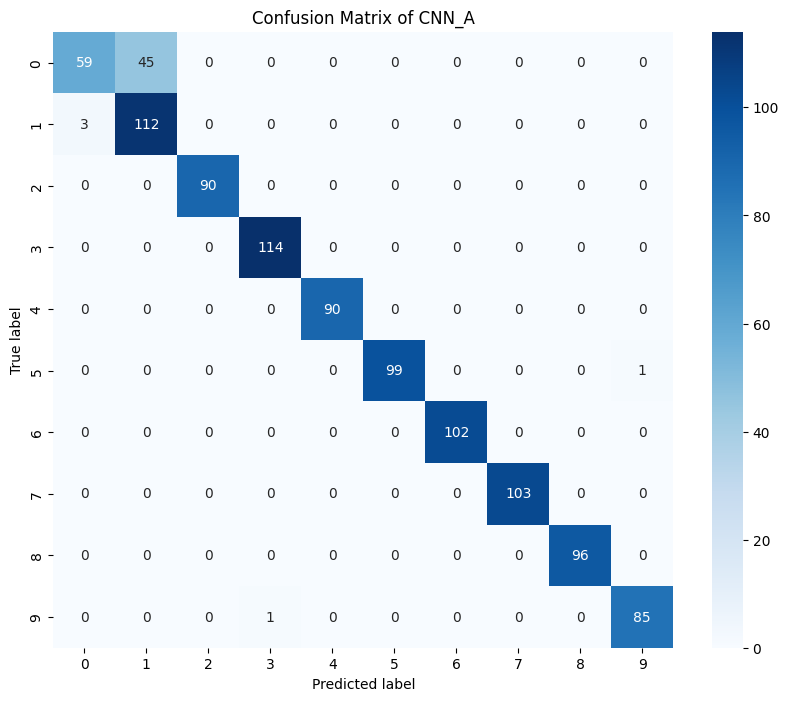

In [60]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN_A')
plt.show()

In [62]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Overall Precision: 0.9600146541481673
Overall Recall: 0.95
Overall F1-Score: 0.9476332640396141


In [50]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(512, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)




/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.1475 - loss: 2.1095 - val_accuracy: 0.4910 - val_loss: 1.1329 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4328 - loss: 1.1735 - val_accuracy: 0.5690 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5247 - loss: 0.9363 - val_accuracy: 0.7270 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5875 - loss: 0.8394 - val_accuracy: 0.7080 - val_loss: 0.6263 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6420 - loss: 0.7197 - val_accuracy: 0.7980 - val_loss: 0.4789 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6941 - loss: 0.6248 - val_accuracy: 0.8720 - val_loss: 0.3955 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7466 - loss: 0.

In [51]:
model_to_train.save('CNN_B_model.h5')

In [52]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('CNN_B_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 94.30%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


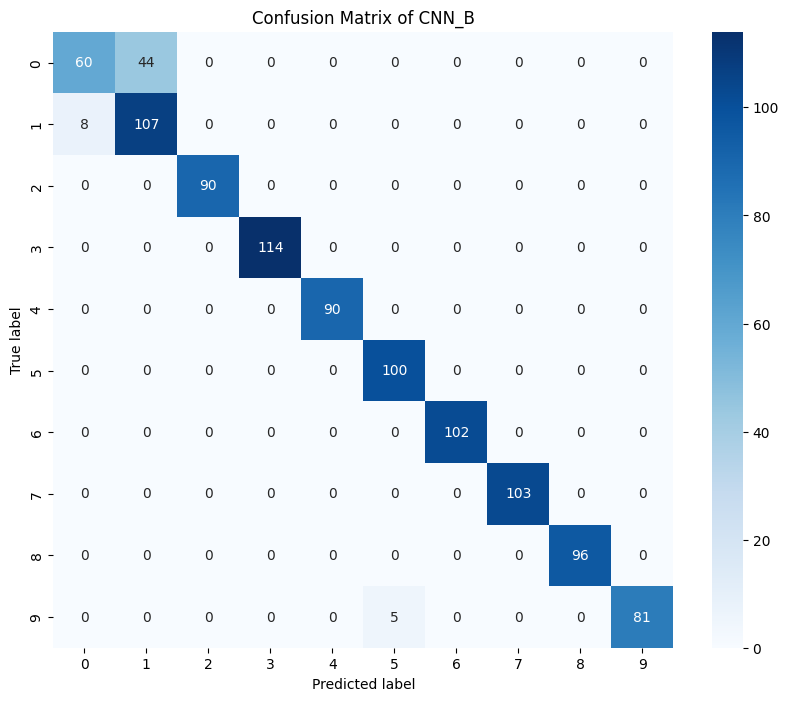

In [53]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN_B')
plt.show()

In [54]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Overall Precision: 0.9494928673456138
Overall Recall: 0.943
Overall F1-Score: 0.9410630618377198


In [69]:
model_to_train.save('cnn2_model.h5')

In [66]:
model_to_train.save('cnn1_model.h5')

In [ ]:
model_to_train.save('lstm_model.h5')

In [63]:

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Bidirectional, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
Bilstm_model = Sequential()

# Add a Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(data_real_values.shape[1], 2)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(64)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.5))

# Add a Dense layer
Bilstm_model.add(Dense(512, activation='relu'))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.5))

# Output layer with 10 neurons for multi-class classification
Bilstm_model.add(Dense(10, activation='softmax'))

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


model_to_train = Bilstm_model




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=60, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


In [65]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


model_to_train = Bilstm_model




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=60, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Epoch 1/60


125/125 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.2171 - loss: 2.6967 - val_accuracy: 0.1150 - val_loss: 2.5421 - learning_rate: 0.0010
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.3211 - loss: 1.8351 - val_accuracy: 0.3210 - val_loss: 1.9233 - learning_rate: 0.0010
Epoch 3/60
 76/125 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3955 - loss: 1.5707 

KeyboardInterrupt: 

In [59]:
model_to_train.save('Bilstm_model.h5')

In [60]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('Bilstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 95.80%


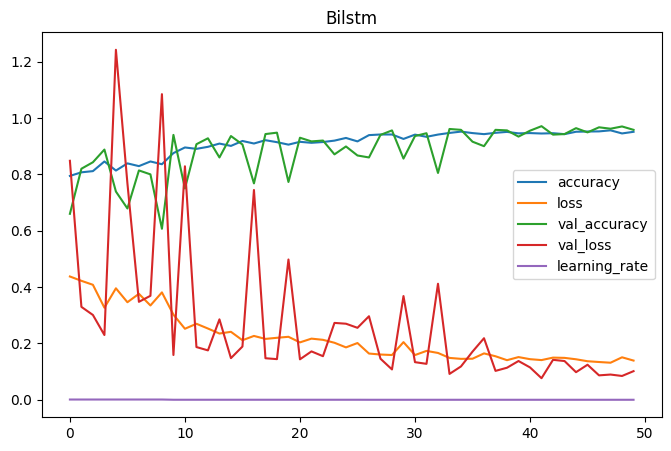

In [61]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'Bilstm')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 367ms/step


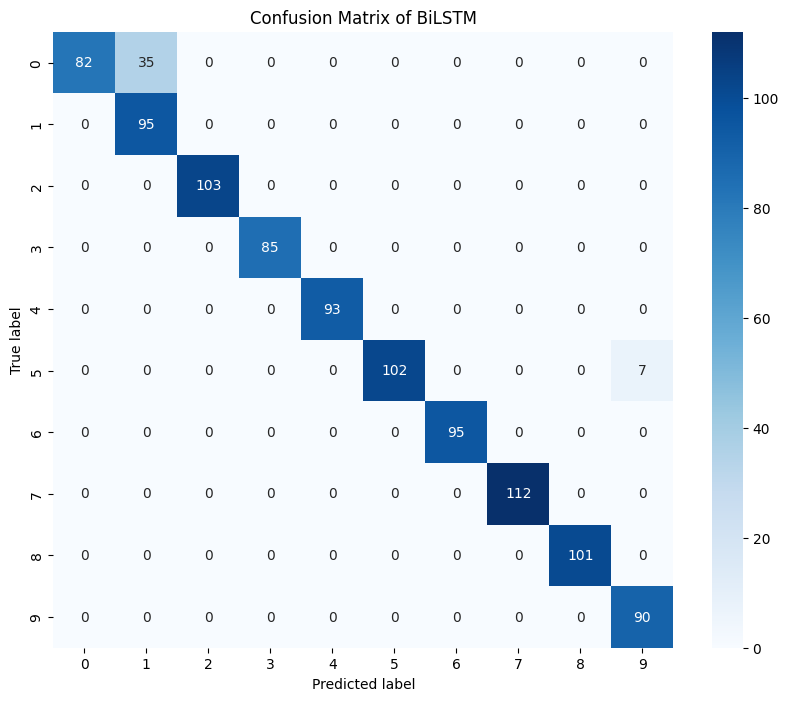

In [64]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [63]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


 1/32 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step
Overall Precision: 0.9679282315622523
Overall Recall: 0.958
Overall F1-Score: 0.957659235073691


In [ ]:
PCA

In [73]:
normalized_data

array([[ 0.48680293+0.j        ,  0.28726283+0.j        ,
         0.05097947+0.j        , ..., -0.14798611+0.j        ,
        -0.12929718+0.j        , -0.08893212+0.j        ],
       [ 0.71024344+0.j        ,  0.67169774-0.00824339j,
         0.5544363 -0.01361065j, ..., -0.15581907-0.01921845j,
        -0.18049711-0.02001675j, -0.18712367-0.01843007j],
       [ 0.41673196+0.j        ,  0.58885514-0.0072267j ,
         0.69008547-0.01694065j, ..., -0.03871343-0.00477485j,
        -0.10011625-0.01110268j, -0.16114352-0.01587125j],
       ...,
       [ 1.57954798+0.j        ,  1.71035746-0.0209903j ,
         1.62931072-0.03999733j, ..., -0.18322905-0.02259915j,
        -0.34440372-0.03819365j, -0.43899146-0.04323689j],
       [ 1.51567575+0.j        ,  1.14305956-0.01402816j,
         0.64706406-0.01588453j, ..., -0.41191785-0.05080522j,
        -0.45417546-0.05036711j, -0.43901721-0.04323942j],
       [-0.84109049+0.j        , -0.27696044+0.00339899j,
         0.32211246-0.00790742

/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 86.70%
Accuracy: 86.70%
Precision: 87.02%
Recall: 86.70%
F1 Score: 86.73%


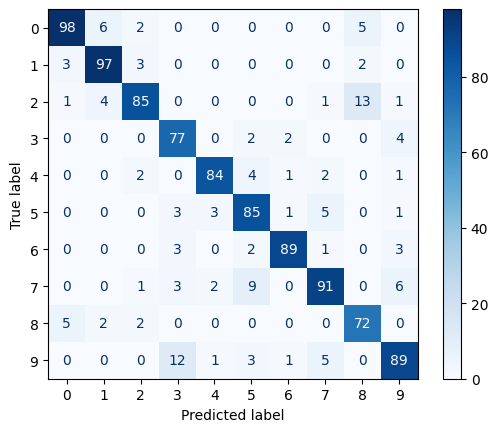

In [63]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data         #np.array([[...], [...], ...])  # complex-valued data array
label = label                #np.array([...])  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=60, random_state=42)
clf.fit(data_train, label_train)

# Predict and evaluate
label_pred = clf.predict(data_test)
accuracy = accuracy_score(label_test, label_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
#PCA=12
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt
# Save the model
joblib.dump(clf, 'random_forest1_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


Accuracy: 90.30%
Precision: 90.51%
Recall: 90.30%
F1 Score: 90.31%


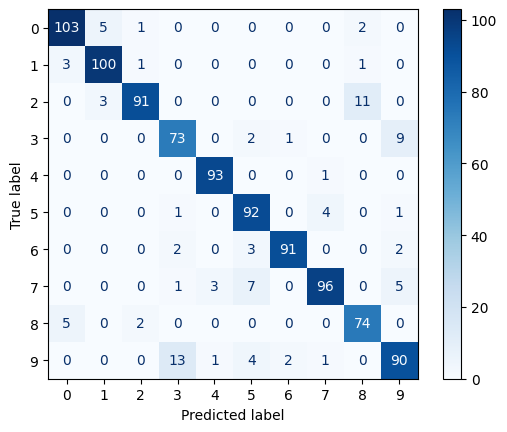

In [62]:
#PCA=12
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt
# Save the model
joblib.dump(clf, 'random_forest1_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [32]:
%pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 6.0 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


Accuracy: 96.60%
Precision: 96.81%
Recall: 96.60%
F1 Score: 96.57%


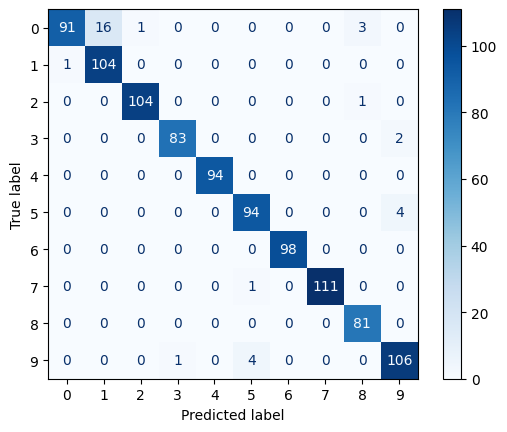

In [36]:
import numpy as np
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx).reshape(n_samples, -1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(data_train, label_train)

# Save the model
joblib.dump(clf, 'xgboost_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


Accuracy: 84.90%
Precision: 85.79%
Recall: 84.90%
F1 Score: 84.97%


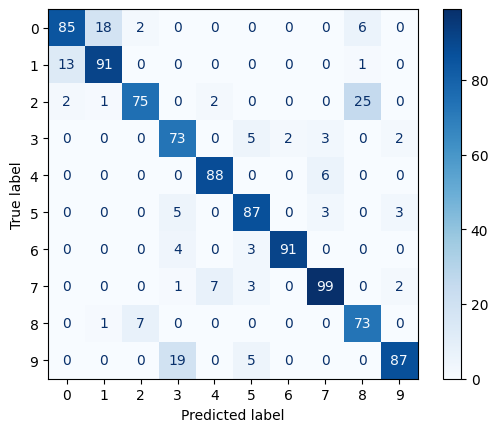

In [35]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(data_train, label_train)

# Save the model
joblib.dump(clf, 'xgboost_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 79.00%
Precision: 79.39%
Recall: 79.00%
F1 Score: 78.88%


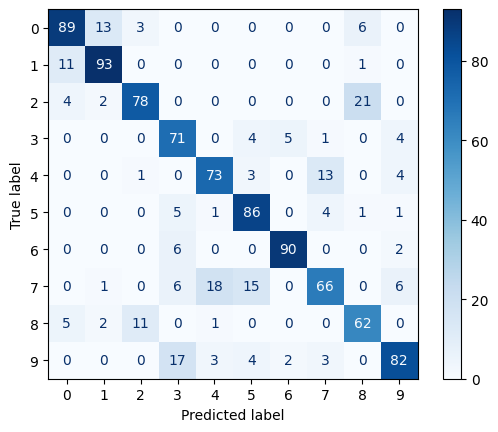

In [30]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=60, random_state=42)
clf.fit(data_train, label_train)

# Save the model
joblib.dump(clf, 'random_forest_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 90.10%
Precision: 90.25%
Recall: 90.10%
F1 Score: 90.11%


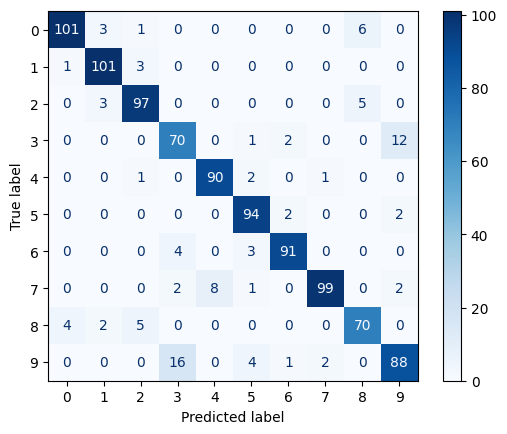

In [104]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=11)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=60, random_state=42)
clf.fit(data_train, label_train)

# Save the model
joblib.dump(clf, 'random_forest_model.pkl')

# Predict and evaluate
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau






Epoch 1/500


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0910 - loss: 2.4498 - val_accuracy: 0.1900 - val_loss: 2.2311
Epoch 2/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1488 - loss: 2.2070 - val_accuracy: 0.2212 - val_loss: 1.9954
Epoch 3/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2077 - loss: 1.9998 - val_accuracy: 0.2087 - val_loss: 1.6509
Epoch 4/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2189 - loss: 1.7573 - val_accuracy: 0.2887 - val_loss: 1.5591
Epoch 5/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2786 - loss: 1.6660 - val_accuracy: 0.3262 - val_loss: 1.4218
Epoch 6/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3516 - loss: 1.5161 - val_accuracy: 0.5512 - val_loss: 1.1162
Epoch 7/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3781 - loss: 1.3483 - val_accuracy: 0.6125 - val_loss: 0.9910
Epoch 8/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4553 - loss: 1.1606 - val_accuracy: 0.4737

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 94.50%
Precision: 0.95
Recall: 0.94
F1 Score: 0.95


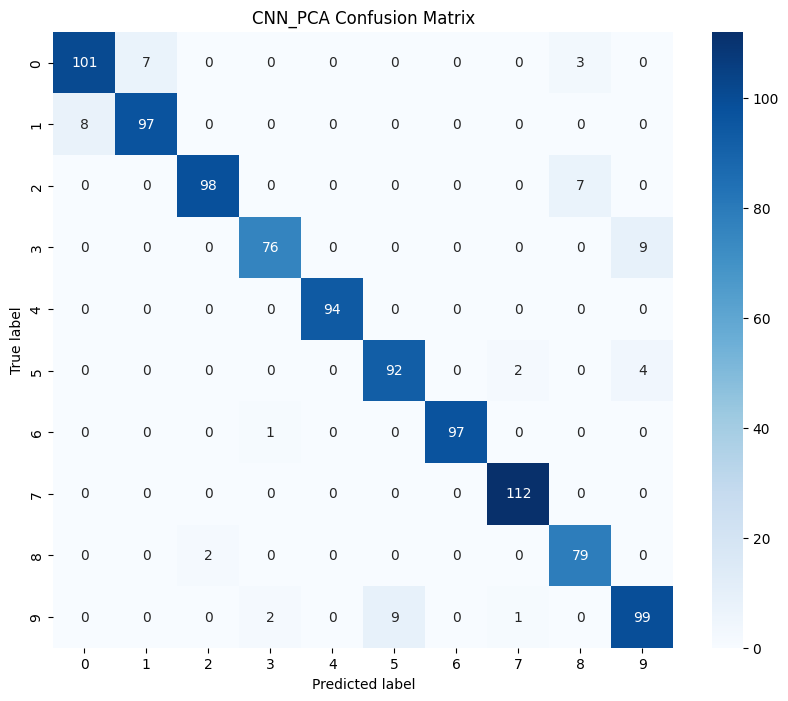

In [122]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=500, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_8_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/1000


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1155 - loss: 2.3414 - val_accuracy: 0.2475 - val_loss: 2.1719
Epoch 2/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1611 - loss: 2.1370 - val_accuracy: 0.2000 - val_loss: 1.8580
Epoch 3/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2153 - loss: 1.8903 - val_accuracy: 0.2362 - val_loss: 1.5791
Epoch 4/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2597 - loss: 1.6950 - val_accuracy: 0.3988 - val_loss: 1.5039
Epoch 5/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3030 - loss: 1.5726 - val_accuracy: 0.4087 - val_loss: 1.2537
Epoch 6/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3761 - loss: 1.4182 - val_accuracy: 0.5437 - val_loss: 1.0916
Epoch 7/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4239 - loss: 1.2585 - val_accuracy: 0.5138 - val_loss: 1.0294
Epoch 8/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4396 - loss: 1.1871 - val_accuracy:

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 91.90%
Precision: 0.92
Recall: 0.92
F1 Score: 0.92


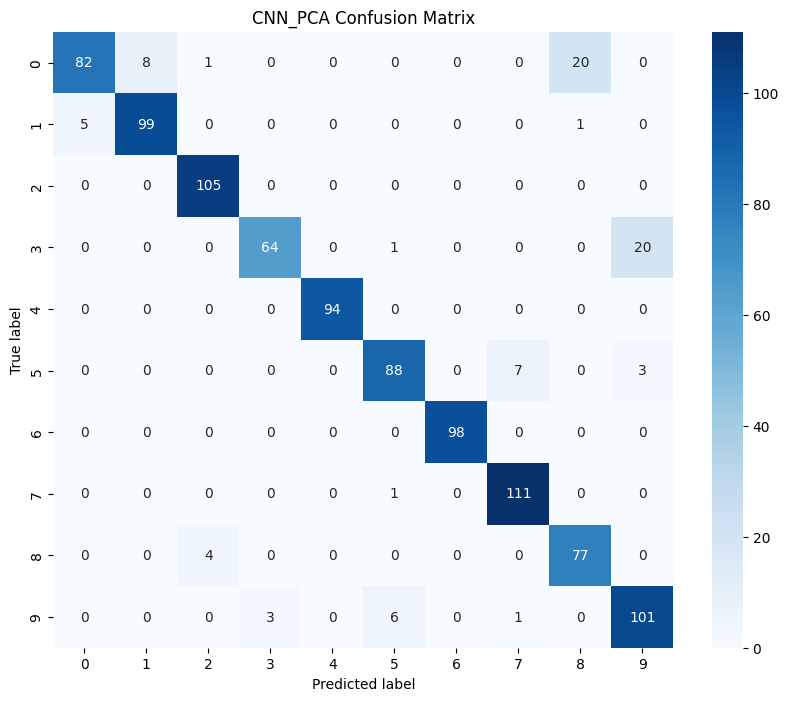

In [121]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=50)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 50, 1, 1)
data_test_reshaped = data_test.reshape(-1, 50, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(50, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=1000, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_6_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/700


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1008 - loss: 2.3435 - val_accuracy: 0.1900 - val_loss: 2.0936
Epoch 2/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1767 - loss: 2.0927 - val_accuracy: 0.2212 - val_loss: 1.6851
Epoch 3/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2209 - loss: 1.7748 - val_accuracy: 0.3537 - val_loss: 1.4260
Epoch 4/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3109 - loss: 1.5766 - val_accuracy: 0.4025 - val_loss: 1.2469
Epoch 5/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3842 - loss: 1.4016 - val_accuracy: 0.4400 - val_loss: 1.0834
Epoch 6/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4215 - loss: 1.2062 - val_accuracy: 0.5113 - val_loss: 0.9413
Epoch 7/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4995 - loss: 1.0546 - val_accuracy: 0.5650 - val_loss: 0.9112
Epoch 8/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4940 - loss: 1.0103 - val_accuracy: 0.5100

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 92.60%
Precision: 0.93
Recall: 0.93
F1 Score: 0.93


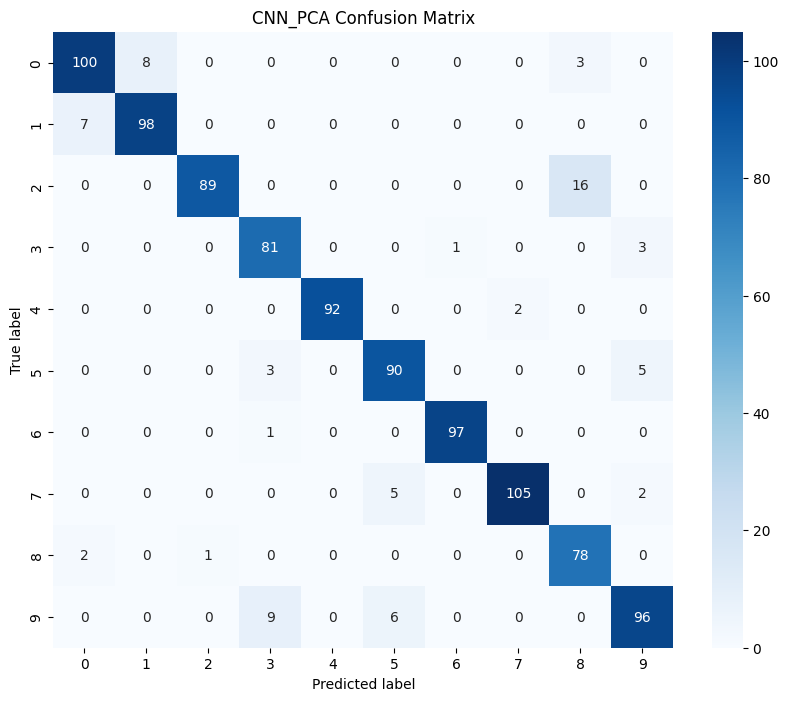

In [118]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=700, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_7_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/1000


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0974 - loss: 2.2933 - val_accuracy: 0.2537 - val_loss: 2.0454
Epoch 2/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2154 - loss: 1.9965 - val_accuracy: 0.2688 - val_loss: 1.6975
Epoch 3/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2487 - loss: 1.6990 - val_accuracy: 0.3938 - val_loss: 1.4708
Epoch 4/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3087 - loss: 1.5393 - val_accuracy: 0.4087 - val_loss: 1.3757
Epoch 5/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4175 - loss: 1.2960 - val_accuracy: 0.5337 - val_loss: 0.9202
Epoch 6/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4595 - loss: 1.1563 - val_accuracy: 0.6225 - val_loss: 0.8727
Epoch 7/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5132 - loss: 1.0223 - val_accuracy: 0.5288 - val_loss: 0.8238
Epoch 8/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4817 - loss: 1.0272 - val_accuracy:

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 93.90%
Precision: 0.94
Recall: 0.94
F1 Score: 0.94


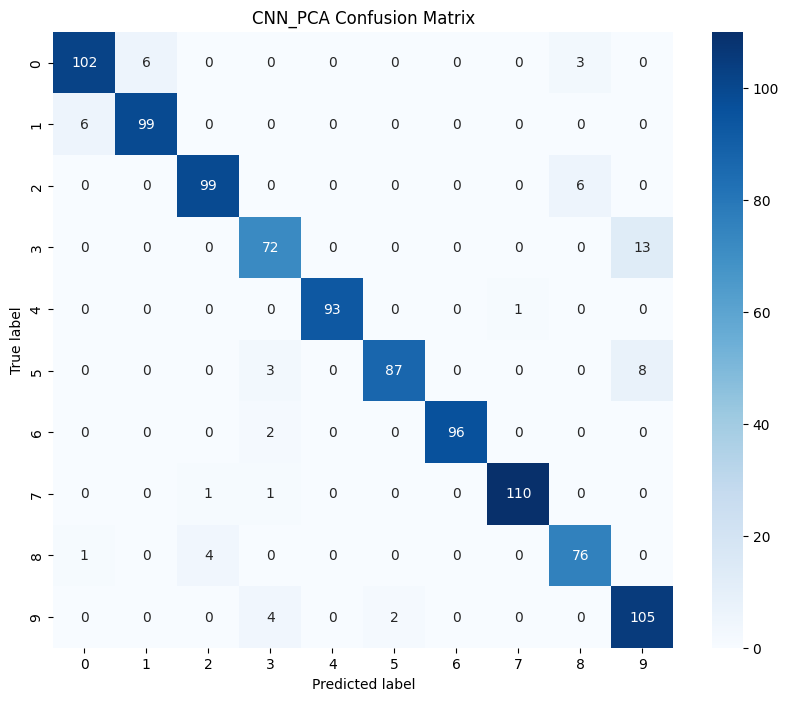

In [116]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=1000, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_5_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/100


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1230 - loss: 2.3423 - val_accuracy: 0.2775 - val_loss: 1.7647
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2430 - loss: 1.7819 - val_accuracy: 0.3900 - val_loss: 1.4131
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3189 - loss: 1.5377 - val_accuracy: 0.4550 - val_loss: 1.1912
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4070 - loss: 1.3270 - val_accuracy: 0.4650 - val_loss: 1.0402
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4672 - loss: 1.1685 - val_accuracy: 0.6075 - val_loss: 0.9050
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4858 - loss: 1.0637 - val_accuracy: 0.6125 - val_loss: 0.8603
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5211 - loss: 0.9854 - val_accuracy: 0.7237 - val_loss: 0.6983
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5495 - loss: 0.9360 - val_accuracy: 0.7150

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 94.10%
Precision: 0.94
Recall: 0.94
F1 Score: 0.94


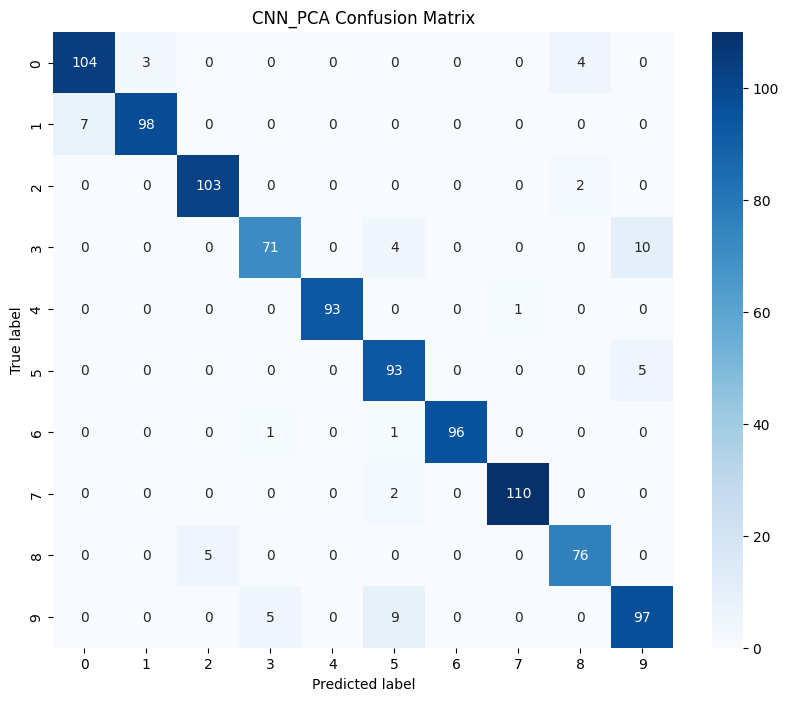

In [113]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [126]:
model.save('CNN_PCA_10_model.h5')

Epoch 1/700


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1171 - loss: 2.2742 - val_accuracy: 0.2475 - val_loss: 1.9853
Epoch 2/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2194 - loss: 1.9444 - val_accuracy: 0.3850 - val_loss: 1.6238
Epoch 3/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2871 - loss: 1.6305 - val_accuracy: 0.4350 - val_loss: 1.2951
Epoch 4/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3859 - loss: 1.3708 - val_accuracy: 0.3750 - val_loss: 1.1393
Epoch 5/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4394 - loss: 1.1874 - val_accuracy: 0.5425 - val_loss: 0.9058
Epoch 6/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4636 - loss: 1.0597 - val_accuracy: 0.5437 - val_loss: 0.8899
Epoch 7/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5164 - loss: 0.9834 - val_accuracy: 0.5587 - val_loss: 0.8081
Epoch 8/700
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5455 - loss: 0.9362 - val_accuracy: 0.8037

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 94.00%
Precision: 0.94
Recall: 0.94
F1 Score: 0.94


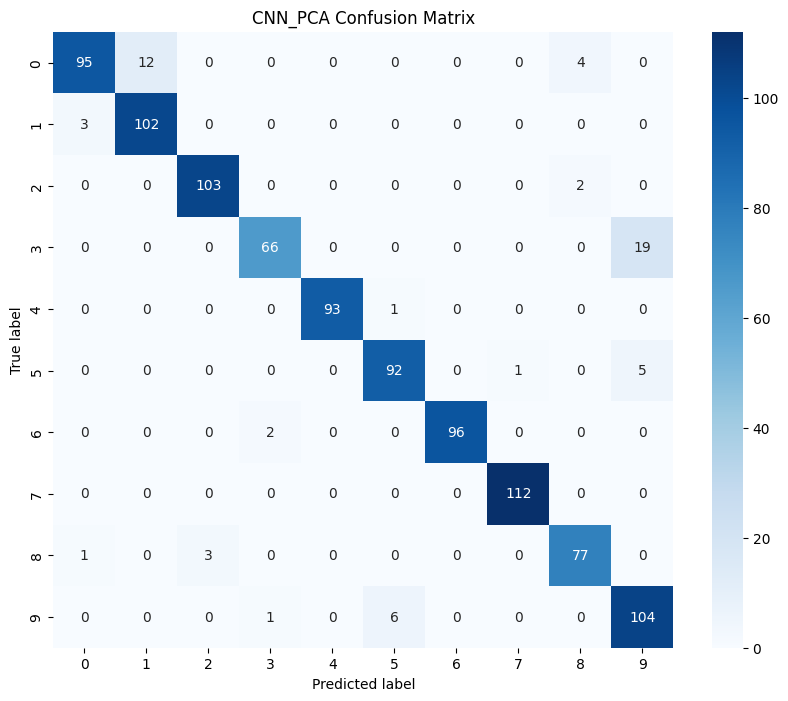

In [111]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=700, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_B_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [128]:
model.save('CNN_PCA_11_model.h5')

In [138]:
normalized_data.shape

(5000, 1017)

Epoch 1/100


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1351 - loss: 2.1497 - val_accuracy: 0.4250 - val_loss: 1.3687
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3945 - loss: 1.3971 - val_accuracy: 0.5225 - val_loss: 1.0882
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4476 - loss: 1.1792 - val_accuracy: 0.3950 - val_loss: 1.2959
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4910 - loss: 1.0992 - val_accuracy: 0.5888 - val_loss: 0.9517
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5978 - loss: 0.8298 - val_accuracy: 0.6600 - val_loss: 0.7385
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5854 - loss: 0.8714 - val_accuracy: 0.7425 - val_loss: 0.5568
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6630 - loss: 0.6470 - val_accuracy: 0.7575 - val_loss: 0.5520
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6737 - loss: 0.6529 - val_accuracy

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Accuracy: 94.60%
Precision: 0.95
Recall: 0.95
F1 Score: 0.95


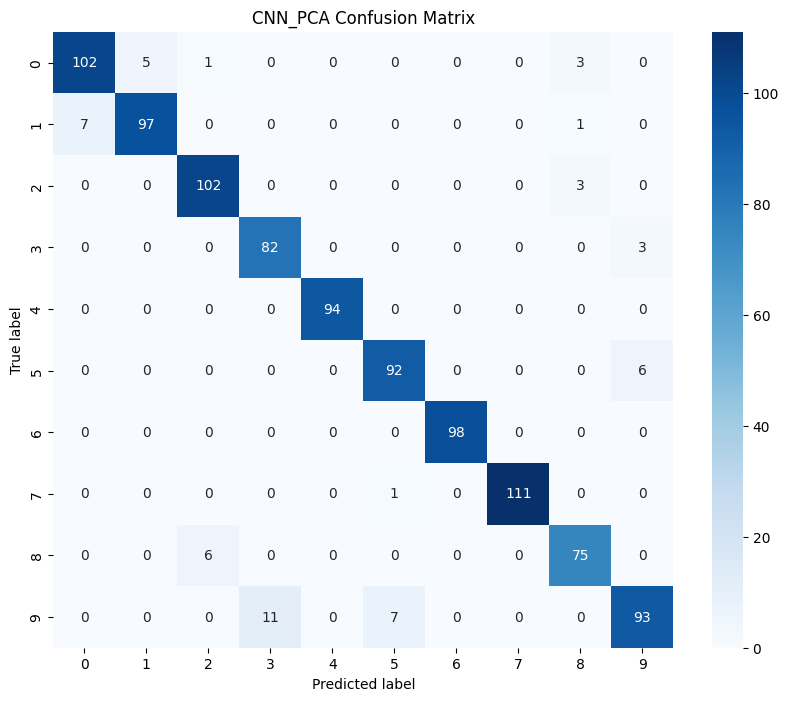

In [140]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22,1, 1)
data_test_reshaped = data_test.reshape(-1, 22,1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model


model = Sequential()

# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(22, 1)))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
model.add(Bidirectional(LSTM(64)))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add a Dense layer
model.add(Dense(128, activation='relu'))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
model.add(Dense(10, activation='softmax'))


# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('BiLSTM_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.1783 - loss: 1.9821 - val_accuracy: 0.5150 - val_loss: 1.0806
Epoch 2/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.5072 - loss: 1.0314 - val_accuracy: 0.4963 - val_loss: 0.9258
Epoch 3/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5792 - loss: 0.7975 - val_accuracy: 0.6500 - val_loss: 0.5956
Epoch 4/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7293 - loss: 0.5597 - val_accuracy: 0.7563 - val_loss: 0.4305
Epoch 5/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6843 - loss: 0.6277 - val_accuracy: 0.7550 - val_loss: 0.4603
Epoch 6/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6288 - loss: 0.7731 - val_accuracy: 0.7688 - val_loss: 0.4486
Epoch 7/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8111 - loss: 0.4006 - val_accuracy: 0.7850 - val_loss: 0.5185
Epoch 8/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7861 - loss: 0.4462 - val_a

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Accuracy: 92.00%
Precision: 0.93
Recall: 0.92
F1 Score: 0.92


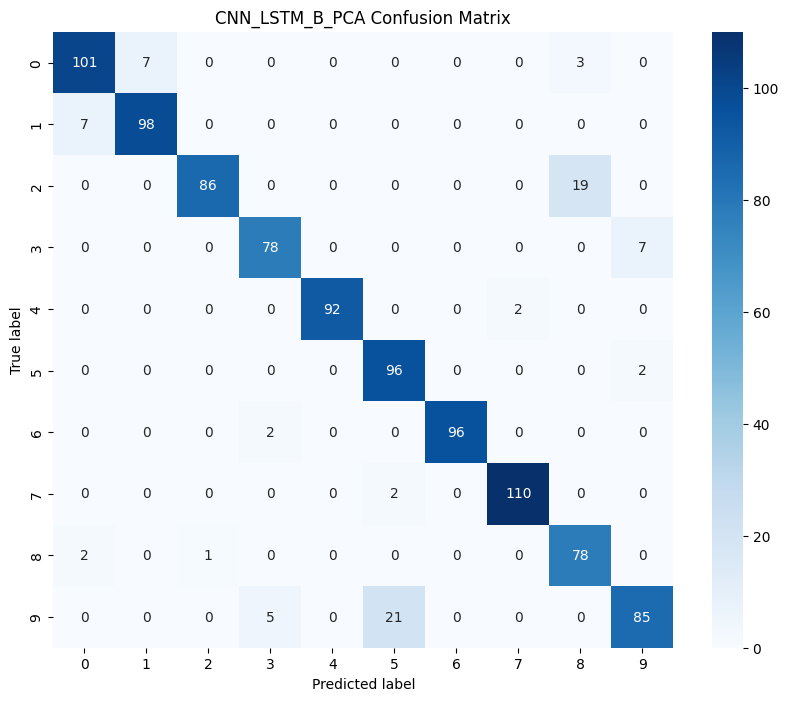

In [150]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Input, Reshape, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22,1, 1)
data_test_reshaped = data_test.reshape(-1, 22,1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Define input shape
input_shape = (22, 1, 1)

# Define input layer
inputs = Input(shape=input_shape)

# Convolutional layers
conv1 = Conv2D(32, kernel_size=(3, 1), activation='relu')(inputs)
pool1 = MaxPooling2D(pool_size=(2, 1))(conv1)
conv2 = Conv2D(64, kernel_size=(3, 1), activation='relu')(pool1)
pool2 = MaxPooling2D(pool_size=(2, 1))(conv2)
conv3 = Conv2D(64, kernel_size=(3, 1), activation='relu')(pool2)
pool3 = MaxPooling2D(pool_size=(2, 1))(conv3)

# Flatten the output of the convolutional layers
flatten = Flatten()(pool3)

# Reshape for LSTM input
reshaped = Reshape((64, 1))(flatten)  # Adjust the shape as needed for LSTM input

# Bidirectional LSTM layers
lstm1 = Bidirectional(LSTM(128, return_sequences=True))(reshaped)
lstm2 = Bidirectional(LSTM(64))(lstm1)

# Fully connected layers
dense1 = Dense(128, activation='relu')(lstm2)
output = Dense(10, activation='softmax')(dense1)

# Define the model
model = Model(inputs=inputs, outputs=output)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
#model.summary()




# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=60, validation_split=0.2)

# Save the trained model
model.save('CNN_BiLSTM_PCA_B_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_LSTM_B_PCA Confusion Matrix')
plt.show()


Epoch 1/100


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1351 - loss: 2.1497 - val_accuracy: 0.4250 - val_loss: 1.3687
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3945 - loss: 1.3971 - val_accuracy: 0.5225 - val_loss: 1.0882
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4476 - loss: 1.1792 - val_accuracy: 0.3950 - val_loss: 1.2959
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4910 - loss: 1.0992 - val_accuracy: 0.5888 - val_loss: 0.9517
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5978 - loss: 0.8298 - val_accuracy: 0.6600 - val_loss: 0.7385
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5854 - loss: 0.8714 - val_accuracy: 0.7425 - val_loss: 0.5568
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6630 - loss: 0.6470 - val_accuracy: 0.7575 - val_loss: 0.5520
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6737 - loss: 0.6529 - val_accuracy

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Accuracy: 94.60%
Precision: 0.95
Recall: 0.95
F1 Score: 0.95


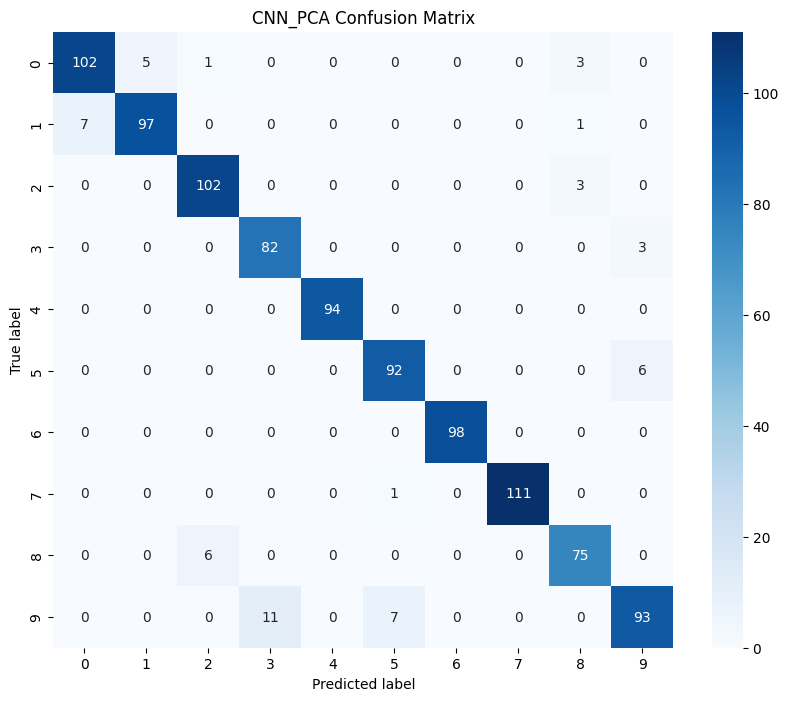

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22,1, 1)
data_test_reshaped = data_test.reshape(-1, 22,1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model


model = Sequential()

# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(22, 1)))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
model.add(Bidirectional(LSTM(64)))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add a Dense layer
model.add(Dense(128, activation='relu'))
#model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
model.add(Dense(10, activation='softmax'))


# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('BiLSTM_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


Epoch 1/100


100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.2365 - loss: 1.8658 - val_accuracy: 0.4963 - val_loss: 1.0799
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.5109 - loss: 1.0541 - val_accuracy: 0.6700 - val_loss: 0.6986
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6608 - loss: 0.6821 - val_accuracy: 0.7038 - val_loss: 0.6176
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7219 - loss: 0.5835 - val_accuracy: 0.7150 - val_loss: 0.5946
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.7545 - loss: 0.5190 - val_accuracy: 0.5562 - val_loss: 1.3268
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7224 - loss: 0.6370 - val_accuracy: 0.6288 - val_loss: 0.8356
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7027 - loss: 0.6173 - val_accuracy: 0.7638 - val_loss: 0.4720
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.7721 - loss: 0.4417 - val_accur

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
Accuracy: 92.50%
Precision: 0.93
Recall: 0.93
F1 Score: 0.92


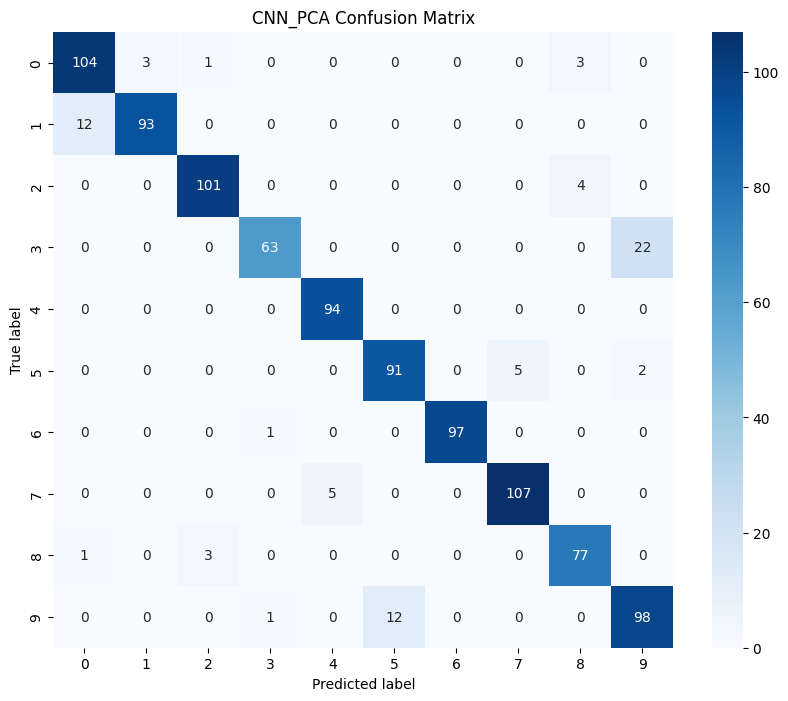

In [149]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Input, Reshape, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22,1, 1)
data_test_reshaped = data_test.reshape(-1, 22,1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Define input shape
input_shape = (22, 1, 1)

# Define input layer
inputs = Input(shape=input_shape)

# Convolutional layers
conv1 = Conv2D(32, kernel_size=(3, 1), activation='relu')(inputs)
pool1 = MaxPooling2D(pool_size=(2, 1))(conv1)
conv2 = Conv2D(64, kernel_size=(3, 1), activation='relu')(pool1)
pool2 = MaxPooling2D(pool_size=(2, 1))(conv2)
conv3 = Conv2D(64, kernel_size=(3, 1), activation='relu')(pool2)
pool3 = MaxPooling2D(pool_size=(2, 1))(conv3)

# Flatten the output of the convolutional layers
flatten = Flatten()(pool3)

# Reshape for LSTM input
reshaped = Reshape((64, 1))(flatten)  # Adjust the shape as needed for LSTM input

# Bidirectional LSTM layers
lstm1 = Bidirectional(LSTM(128, return_sequences=True))(reshaped)
lstm2 = Bidirectional(LSTM(64))(lstm1)

# Fully connected layers
dense1 = Dense(128, activation='relu')(lstm2)
output = Dense(10, activation='softmax')(dense1)

# Define the model
model = Model(inputs=inputs, outputs=output)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
#model.summary()




# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('CNN_BiLSTM_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from scipy.signal import stft
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns




In [65]:
# Assuming data_real is your time-domain data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # time-domain data array
label = label  # corresponding labels

# Function to compute the spectrogram without sample rate
def compute_spectrogram(data, nperseg=256, noverlap=128):
    f, t, Z = stft(data, window='hann', nperseg=nperseg, noverlap=noverlap, return_onesided=False)
    Z = np.fft.fftshift(Z, axes=0)  # Shift the zero frequency component to the center of the spectrum
    spectrogram_data = np.log(np.abs(Z) + 1e-10)  # Logarithm of the magnitude for better visualization
    return spectrogram_data, f, t

# Compute spectrogram for each sample
spectrograms = []
for sample in data_real:
    spec, f, t = compute_spectrogram(sample)
    spectrograms.append(spec)

spectrograms = np.array(spectrograms)

# Reshape spectrogram data to 2D array (samples x features)
n_samples, n_freq_bins, n_time_bins = spectrograms.shape
spectrogram_2d = spectrograms.reshape(n_samples, n_freq_bins * n_time_bins)



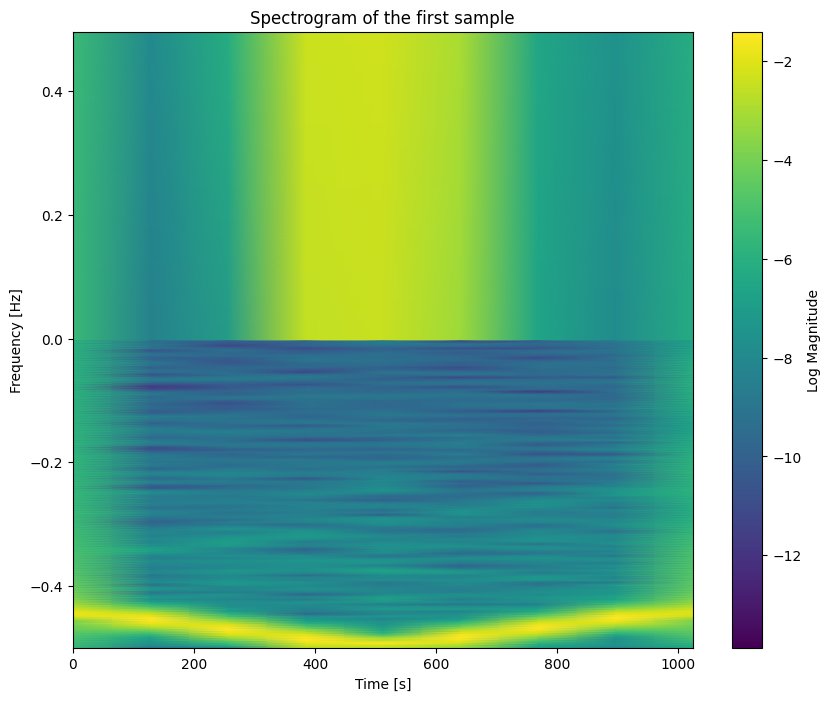

In [66]:
# Plot the spectrogram for the first sample
plt.figure(figsize=(10, 8))
plt.pcolormesh(t, f, spectrograms[0], shading='gouraud')
plt.title('Spectrogram of the first sample')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='Log Magnitude')
plt.show()

In [47]:
spectrograms

array([[[ -5.84388721, -10.74411452, -11.91031032, ..., -11.33234339,
         -10.98062511,  -6.10340438],
        [ -5.85427051,  -9.87297216, -10.23351643, ..., -11.72403572,
          -8.79819005,  -6.10645782],
        [ -5.8708662 ,  -9.37820601, -10.10673131, ...,  -9.9924023 ,
          -9.11683641,  -6.12071559],
        ...,
        [ -5.88055416,  -8.97570624, -10.14787317, ...,  -9.81732137,
          -8.78161735,  -6.14782777],
        [ -5.8708662 ,  -9.37820601, -10.10673131, ...,  -9.9924023 ,
          -9.11683641,  -6.12071559],
        [ -5.85427051,  -9.87297216, -10.23351643, ..., -11.72403572,
          -8.79819005,  -6.10645782]],

       [[ -6.71670786,  -8.25655688,  -7.38564028, ...,  -8.11057815,
          -8.09500473,  -5.67881853],
        [ -6.48784575,  -8.34503249,  -7.84460309, ...,  -7.57969062,
          -7.50485805,  -5.65159974],
        [ -6.27291062,  -7.99679966,  -9.27290202, ...,  -7.89287591,
          -7.56314244,  -5.6727254 ],
        ...,


In [48]:
spectrograms.shape

(5000, 256, 9)

In [67]:
import numpy as np

# Assuming 'compensated_data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(spectrograms)
imaginary_part = np.imag(spectrograms)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 2D CNN with spectrogram shape
data_reshaped = data_normalized.reshape((spectrograms.shape[0], spectrograms.shape[1], spectrograms.shape[2], 2))

# Now 'data_reshaped' can be used as input to your 2D CNN model


/tmp/ipykernel_3258/3520105715.py:10: RuntimeWarning: invalid value encountered in divide
  imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)


In [49]:
data_reshaped.shape[2]

9

In [68]:
import numpy as np
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

# Assuming data_real is your time-domain data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # time-domain data array
label = label  # corresponding labels

# Function to compute the spectrogram without sample rate
def compute_spectrogram(data, nperseg=256, noverlap=128):
    f, t, Z = stft(data, window='hann', nperseg=nperseg, noverlap=noverlap, return_onesided=False)
    Z = np.fft.fftshift(Z, axes=0)  # Shift the zero frequency component to the center of the spectrum
    spectrogram_data = np.log(np.abs(Z) + 1e-10)  # Logarithm of the magnitude for better visualization
    return spectrogram_data, f, t

# Compute spectrogram for each sample
spectrograms = []
for sample in data_real:
    spec, f, t = compute_spectrogram(sample)
    spectrograms.append(spec)

spectrograms = np.array(spectrograms)


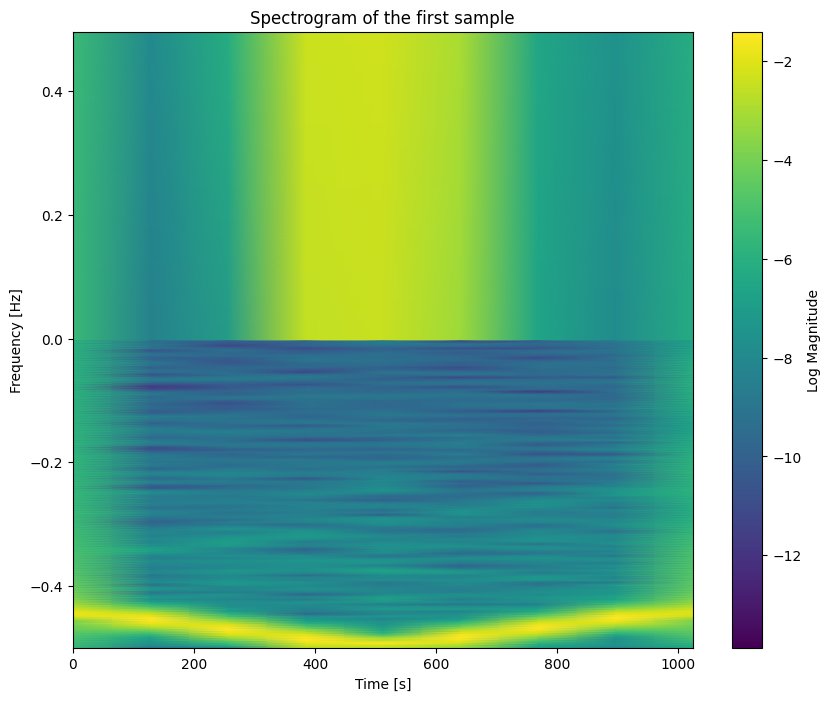

In [69]:
# Plot the spectrogram for the first sample
plt.figure(figsize=(10, 8))
plt.pcolormesh(t, f, spectrograms[0], shading='gouraud')
plt.title('Spectrogram of the first sample')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='Log Magnitude')
plt.show()

In [72]:

# Reshape spectrogram data to 4D array (samples, freq_bins, time_bins, channels)
n_samples, n_freq_bins, n_time_bins = spectrograms.shape
spectrogram_4d = spectrograms.reshape(n_samples, n_freq_bins, n_time_bins, 1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(spectrogram_4d, label, test_size=0.2, random_state=42)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(n_freq_bins, n_time_bins, 1), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

# Train the model
model.fit(data_train, label_train_categorical, batch_size=32, epochs=1020, validation_split=0.2)

# Save the trained model
model.save('CNN_Spectrogram_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_Spectrogram Confusion Matrix')
plt.show()


Epoch 1/1020


100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.1067 - loss: 2.8951 - val_accuracy: 0.1013 - val_loss: 2.3062
Epoch 2/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.1443 - loss: 2.2539 - val_accuracy: 0.1025 - val_loss: 2.2563
Epoch 3/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.1800 - loss: 2.2165 - val_accuracy: 0.1400 - val_loss: 2.2269
Epoch 4/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.1668 - loss: 2.1941 - val_accuracy: 0.1625 - val_loss: 2.1336
Epoch 5/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.1780 - loss: 2.1343 - val_accuracy: 0.1500 - val_loss: 2.0876
Epoch 6/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.1806 - loss: 2.1284 - val_accuracy: 0.2138 - val_loss: 2.0385
Epoch 7/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.1905 - loss: 2.1055 - val_accuracy: 0.2000 - val_loss: 1.9996
Epoch 8/1020
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.1800 - loss: 2.1112 - val

In [52]:


# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(data_reshaped, label, test_size=0.2, random_state=42)



# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)


model = Sequential()
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=(256, 9, 2)))

#model.add(Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=(input_shape[1], input_shape[2], 2)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(1, 1), activation='relu'))#model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())  # Flatten the output of Conv2D layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))






# Reshape the input data to add the missing channel dimension
#data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], data_train.shape[2], 1)
#data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], data_test.shape[2], 1)



# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train, label_train_categorical, batch_size=32, epochs=200, validation_split=0.2)

# Save the trained model
model.save('CNN_Spectrogram_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_Spectrogram Confusion Matrix')
plt.show()


Epoch 1/200


2024-06-09 16:11:49.670473: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58982400 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0957 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.1031 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0989 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1007 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0987 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0956 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0998 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 8/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0917 - loss: nan - val_accuracy: 0.0838 - val_loss: nan
Epoch 9/200
100/100 

KeyboardInterrupt: 

In [171]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming input_array_reshaped is your reshaped data
input_array_reshaped = input_array.reshape(input_array.shape[0], input_array.shape[1], input_array.shape[2], 1)

# Flatten the data to 2D for normalization (samples, features)
n_samples, height, width, channels = input_array_reshaped.shape
input_array_flat = input_array_reshaped.reshape(n_samples, height * width * channels)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
input_array_scaled = scaler.fit_transform(input_array_flat)

# Reshape back to original dimensions
input_array_scaled = input_array_scaled.reshape(n_samples, height, width, channels)

print("Min-Max Scaled shape:", input_array_scaled.shape)


Min-Max Scaled shape: (5000, 256, 9, 1)


In [173]:
input_array_scaled.shape

(5000, 256, 9, 1)

In [177]:
input_array_scaled[1].shape

(256, 9, 1)

In [212]:


# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(input_array_scaled, label, test_size=0.2, random_state=42)

input_shape = data_train.shape[1:]

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)


model = Sequential()
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=(input_shape[1], input_shape[2], 1)))

#model.add(Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=(input_shape[1], input_shape[2], 2)))
#model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(1, 1), activation='relu'))
#model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(1, 1), activation='relu'))
#model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())  # Flatten the output of Conv2D layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()




# Reshape the input data to add the missing channel dimension
data_train_reshaped = data_train.reshape(data_train.shape[0], data_train.shape[1], data_train.shape[2], 1)
data_test_reshaped = data_test.reshape(data_test.shape[0], data_test.shape[1], data_test.shape[2], 1)
print("Shape of data_train_reshaped:", data_train_reshaped.shape)
print("Shape of data_test_reshaped:", data_test_reshaped.shape)



# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=200, validation_split=0.2)

# Save the trained model
model.save('CNN_Spectrogram_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_Spectrogram Confusion Matrix')
plt.show()


Model: "sequential_104"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_150 (Conv2D)             │ (None, 9, 1, 32)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ (None, 9, 1, 64)       │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 9, 1, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_50 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_133 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_134 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,098 (348.04 KB)

 Trainable params: 89,098 (348.04 KB)

 Non-trainable params: 0 (0.00 B)

Shape of data_train_reshaped: (4000, 256, 9, 1)
Shape of data_test_reshaped: (1000, 256, 9, 1)
Epoch 1/200


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_169" is incompatible with the layer: expected axis -1 of input shape to have value 576, but received input with shape (32, 147456)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 256, 9, 1), dtype=float32)
  • training=True
  • mask=None

Epoch 1/150


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.1473 - loss: 2.8298 - val_accuracy: 0.2550 - val_loss: 2.1649
Epoch 2/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2689 - loss: 2.1034 - val_accuracy: 0.3050 - val_loss: 1.8408
Epoch 3/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3142 - loss: 1.8157 - val_accuracy: 0.3212 - val_loss: 1.5649
Epoch 4/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3598 - loss: 1.5436 - val_accuracy: 0.3400 - val_loss: 1.3711
Epoch 5/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3942 - loss: 1.4055 - val_accuracy: 0.5225 - val_loss: 1.0670
Epoch 6/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4465 - loss: 1.2313 - val_accuracy: 0.4038 - val_loss: 1.2129
Epoch 7/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4835 - loss: 1.1119 - val_accuracy: 0.5975 - val_loss: 0.8466
Epoch 8/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5271 - loss: 1.0356 - val_accuracy

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Accuracy: 87.60%
Precision: 0.88
Recall: 0.88
F1 Score: 0.88


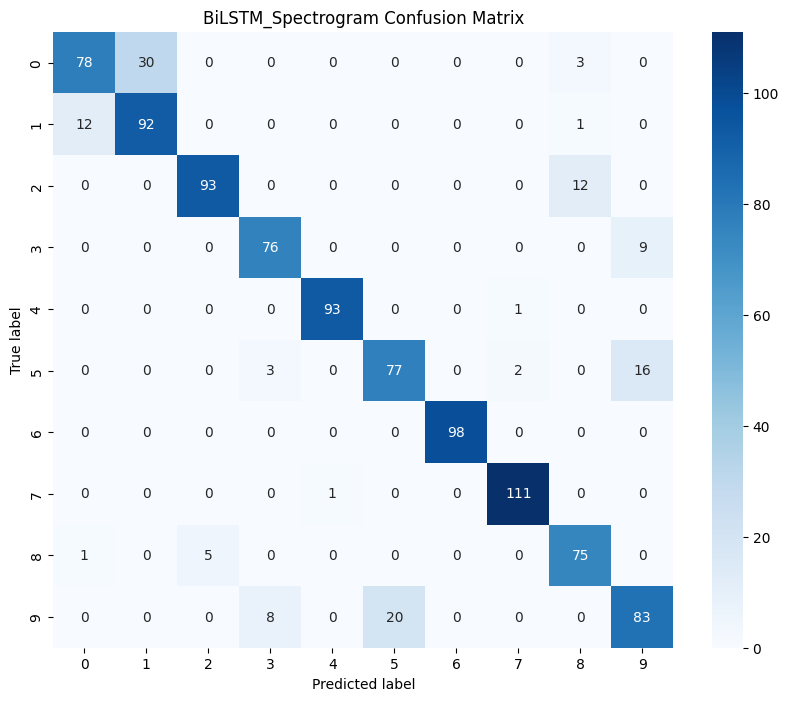

In [182]:


# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(input_array_scaled, label, test_size=0.2, random_state=42)

input_shape = data_train.shape[1:]

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)


model = Sequential()

# Add a Bidirectional LSTM layer
# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(input_shape[1], 1)))
#model.add((Bidirectional(LSTM(128, return_sequences=True), input_shape=(input_array_scaled[1],1))))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
model.add(Bidirectional(LSTM(64)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add a Dense layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=150, validation_split=0.2)

# Save the trained model
model.save('BiLSTM_Spectrogram1_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('BiLSTM_Spectrogram Confusion Matrix')
plt.show()


Epoch 1/100


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.1376 - loss: 2.8328 - val_accuracy: 0.1925 - val_loss: 2.2012
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2507 - loss: 2.1608 - val_accuracy: 0.2713 - val_loss: 1.8867
Epoch 3/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3229 - loss: 1.7759

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3231 - loss: 1.7752 - val_accuracy: 0.3225 - val_loss: 1.6337
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3552 - loss: 1.5387 - val_accuracy: 0.4375 - val_loss: 1.2761
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4352 - loss: 1.3730 - val_accuracy: 0.5000 - val_loss: 1.0287
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4653 - loss: 1.2068 - val_accuracy: 0.5725 - val_loss: 0.9374
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5101 - loss: 1.1074 - val_accuracy: 0.6288 - val_loss: 0.8394
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5258 - loss: 1.0193 - val_accuracy: 0.6338 - val_loss: 0.7836
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5476 - loss: 0.9603 - val_accuracy: 0.6313 - val_loss: 0.7469
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5684 - loss: 0.9045 - val_accurac

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Accuracy: 86.20%
Precision: 0.87
Recall: 0.86
F1 Score: 0.86


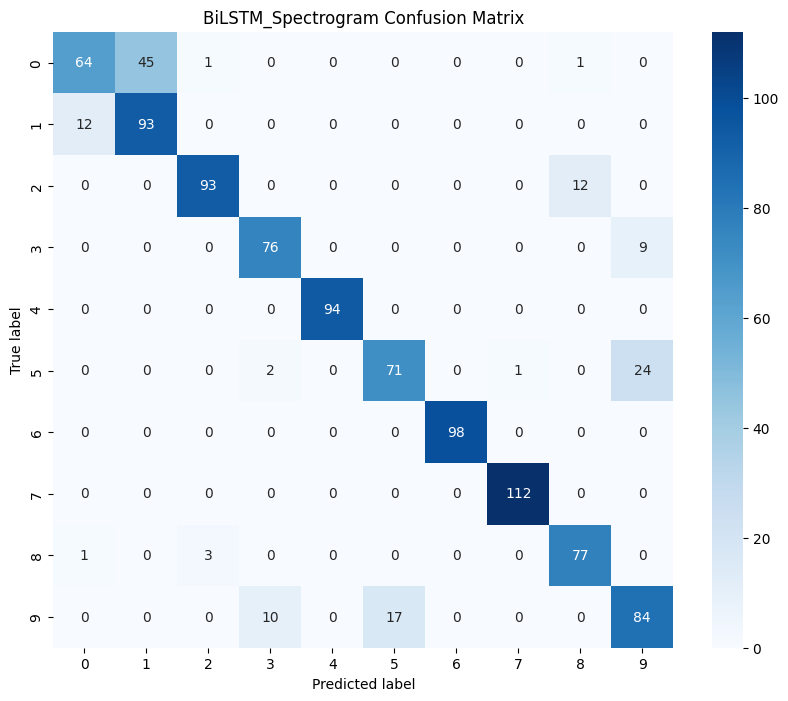

In [181]:


# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(input_array_scaled, label, test_size=0.2, random_state=42)

input_shape = data_train.shape[1:]

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)


model = Sequential()

# Add a Bidirectional LSTM layer
# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(input_shape[1], 1)))
#model.add((Bidirectional(LSTM(128, return_sequences=True), input_shape=(input_array_scaled[1],1))))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
model.add(Bidirectional(LSTM(64)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add a Dense layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)

# Save the trained model
model.save('BiLSTM_Spectrogram_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('BiLSTM_Spectrogram Confusion Matrix')
plt.show()


Epoch 1/200


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1554 - loss: 2.2900 - val_accuracy: 0.2950 - val_loss: 1.7198
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3141 - loss: 1.7328 - val_accuracy: 0.3938 - val_loss: 1.2938
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4073 - loss: 1.3671 - val_accuracy: 0.5362 - val_loss: 0.9695
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4656 - loss: 1.1293 - val_accuracy: 0.6112 - val_loss: 0.8126
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5398 - loss: 0.9715 - val_accuracy: 0.7113 - val_loss: 0.7043
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5857 - loss: 0.8772 - val_accuracy: 0.6562 - val_loss: 0.6849
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5757 - loss: 0.8373 - val_accuracy: 0.6988 - val_loss: 0.6628
Epoch 8/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6403 - loss: 0.7498 - val_accuracy: 0.7375

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 76.90%
Precision: 0.79
Recall: 0.77
F1 Score: 0.76


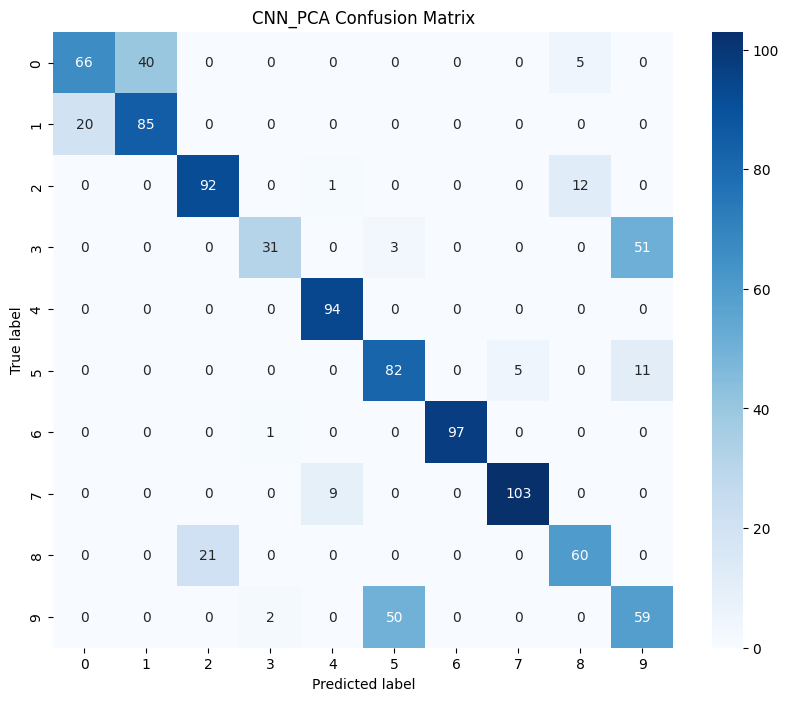

In [163]:

# Standardize the spectrogram data
scaler = StandardScaler()
spectrogram_scaled = scaler.fit_transform(spectrogram_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(spectrogram_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(data_pca, label, test_size=0.2, random_state=42)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=200, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_Spectrogram_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [ ]:
# Apply PCA to downsize spectrogram
pca = PCA(n_components=22)  # Adjust n_components as needed
spectrogram_pca = pca.fit_transform(spectrogram_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    spectrogram_pca, label, test_size=0.2, random_state=42
)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

In [ ]:


# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train.reshape(-1, 22, 1, 1), label_train_categorical, batch_size=32, epochs=700, validation_split=0.2)

# Save the trained model
model.save('CNN_Spectrogram_PCA_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test.reshape(-1, 22, 1, 1))
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN Spectrogram PCA Confusion Matrix')
plt.show()


In [ ]:
# Save the trained model
#model.save('CNN_BiLSTM_PCA_B_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_BiLSTM_PCA Confusion Matrix')
plt.show()

Epoch 1/50


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1245 - loss: 2.3511 - val_accuracy: 0.2537 - val_loss: 1.7861
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2426 - loss: 1.7862 - val_accuracy: 0.4137 - val_loss: 1.4412
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3493 - loss: 1.5258 - val_accuracy: 0.4900 - val_loss: 1.1607
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4271 - loss: 1.3023 - val_accuracy: 0.6450 - val_loss: 0.9486
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4576 - loss: 1.1568 - val_accuracy: 0.5387 - val_loss: 0.9094
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4913 - loss: 1.0239 - val_accuracy: 0.7237 - val_loss: 0.7236
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5513 - loss: 0.9496 - val_accuracy: 0.7125 - val_loss: 0.7158
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5786 - loss: 0.8765 - val_accuracy: 0.7200 - val_

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 94.80%
Precision: 0.95
Recall: 0.95
F1 Score: 0.95


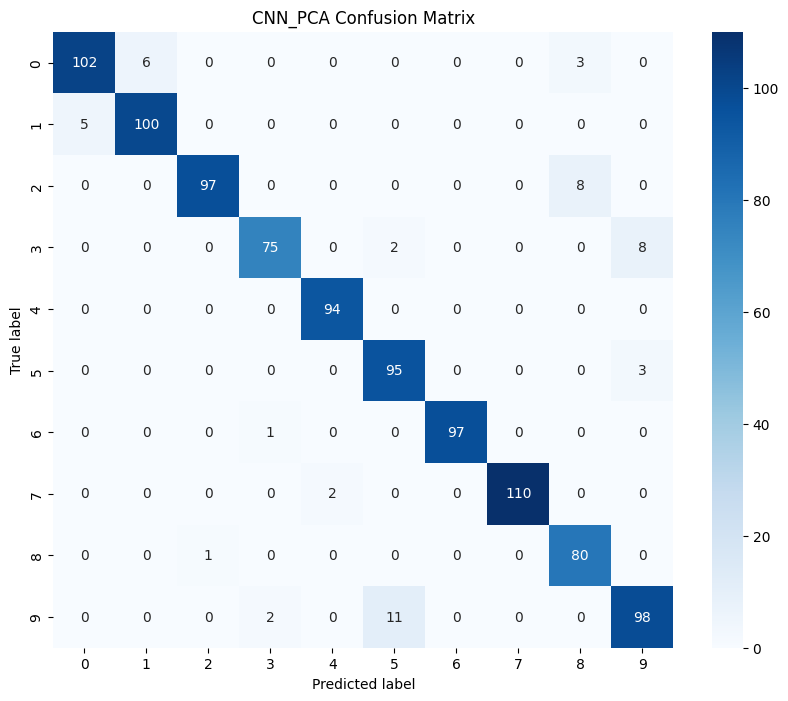

In [107]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Reshape data to match the input shape of the CNN model
data_train_reshaped = data_train.reshape(-1, 22, 1, 1)
data_test_reshaped = data_test.reshape(-1, 22, 1, 1)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_train_reshaped, label_train_categorical, batch_size=32, epochs=50, validation_split=0.2)

# Save the trained model
model.save('CNN_PCA_A_model.h5')

# Obtain predictions on the test set
label_pred = model.predict(data_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA Confusion Matrix')
plt.show()


In [106]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Build the CNN model...
# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Reshape the training and test data to match the input shape of the CNN model
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 22, 1, 1)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 22, 1, 1)

# Train the model
model.fit(data_real_values_train_reshaped, label_train_categorical, batch_size=32, epochs=50, validation_split=0.2)

# Train the model
#model.fit(data_real_values_train, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)v



# Save the trained model
model.save('CNN_PCA_A_model.h5')
# load and evaluate a saved model\n",

# Obtain predictions on the test set
#label_pred = model.predict(data_real_values_test)
# Obtain predictions on the test set
#label_pred = model.predict(data_real_values_test_reshaped)

y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels
label_pred = model.predict(data_real_values_test_reshaped)

y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)




# Predict on test data


# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')




print(f'Accuracy: {accuracy * 100:.2f}%')


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA ')
plt.show()
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')



/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: cannot reshape array of size 8136000 into shape (22,1,1)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply PCA
pca = PCA(n_components=11)  # Adjust n_components as needed
data_pca = pca.fit_transform(data_scaled)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_pca, label, test_size=0.2, random_state=42
)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))



In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import joblib

# Save the trained model
joblib.dump(clf, 'random_forest_model.pkl')

# Predict on test data
label_pred = clf.predict(data_real_values_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
conf_matrix = confusion_matrix(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
#print(f'Confusion Matrix:\n{conf_matrix}')
#y_pred = model_to_train.predict(data_real_values_test)
#y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels
# Compute confusion matrix
#conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of random_forest_model ')
plt.show()
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


# Predict and evaluate
label_pred = clf.predict(data_test)
accuracy = accuracy_score(label_test, label_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


ValueError: Found array with dim 3. RandomForestClassifier expected <= 2.

In [71]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(normalized_data)
imaginary_part = np.imag(normalized_data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real = data_normalized.reshape((data_normalized.shape[0],data_normalized.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [72]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming data is a tuple: (data_real_values, label)
# Uncomment and replace with your actual data loading mechanism
# data_real_values, label = data

# Example dummy data for demonstration purposes (remove this and use your actual data)
# data_real_values = np.random.rand(5000, 7170)
# label = np.random.randint(0, 2, 5000)

# Ensure data is in the correct format
data_real_values, label = data_real

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_real_values.shape
data_real_values_2d = data_real_values.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_scaled)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(data_real_values_train, label_train)

# Predict and evaluate
label_pred = clf.predict(data_real_values_test)
accuracy = accuracy_score(label_test, label_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


# Train the classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(data_real_values_train, label_train)



ValueError: too many values to unpack (expected 2)

In [29]:
input_data=data_real_values

In [ ]:
%pip install librosa

In [ ]:
def train_feature_extractor(
    file_path = 
    #'/workspaces/work/dataset_training_no_aug.h5'
    "/workspaces/work/dataset_training_aug.h5", 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,1000, dtype = int), 
    snr_range = np.arange(20,80)):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
    #######################################################3
    # data = np.real(data).reshape(data.shape[0], 1, data.shape[1])
    # for i in range(data.shape[0]):
    #     data[i] = calculate_rms(data[i])
    ##########################################################
        
    # Add additive Gaussian noise to the IQ samples.
    #data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [ ]:
# Optionally, you can visualize a spectrogram for one sample
#plt.figure(figsize=(10, 4))
#librosa.display.specshow(librosa.amplitude_to_db(spectrograms[0], ref=np.max), sr=44100, hop_length=512, x_axis='time', y_axis='log')
#plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
#plt.show()

In [31]:
spectrograms.shape

(5000, 2, 1025, 15)

In [32]:
spectrograms.shape[1]

2

In [33]:
data_real=spectrograms

In [34]:
#SOME PREPROCESSING

data_real.shape
data_real_train, data_real_test, label_train, label_test = train_test_split(data_real, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [35]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import librosa

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Assuming your input data is stored in a variable called 'X_train', 'X_test', 'y_train', 'y_test'

# Define CNN model
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (1, 1), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(64, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(128, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Initialize model
input_shape = (2,1025, 15)  # Input shape (channels, frequency bins, time bins)
cnn_model = create_cnn_model(input_shape)


# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]
tf.keras.backend.get_session().run(tf.global_variables_initializer())

# Compile the model
model_to_train.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_train, label_train, 
    validation_data=(data_real_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)



Train on 4000 samples, validate on 1000 samples
Epoch 1/50
3968/4000 [============================>.] - ETA: 0s - loss: 14.3659 - acc: 0.0968

FailedPreconditionError: Error while reading resource variable RMSprop/lr from Container: localhost. This could mean that the variable was uninitialized. Not found: Container localhost does not exist. (Could not find resource: localhost/RMSprop/lr)
	 [[node RMSprop/lr/Read/ReadVariableOp (defined at <ipython-input-37-a9ede0bfde32>:44)  = ReadVariableOp[dtype=DT_FLOAT, _device="/job:localhost/replica:0/task:0/device:CPU:0"](RMSprop/lr)]]

Caused by op 'RMSprop/lr/Read/ReadVariableOp', defined at:
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/conda/envs/project/lib/python3.6/site-packages/traitlets/config/application.py", line 664, in launch_instance
    app.start()
  

: 

In [41]:
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Model to train
#model_to_train = models

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=100, batch_size=32,
    callbacks=callbacks,
)


NameError: name 'model' is not defined